# Analisis datos encontrados por medio de grupos

## Carga de librerias
Empezamos cargando librerias.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

## Carga y formateo
- Cargo los datos 
- Creo grupos interesantes apartando la hora y los minutos para pasar al algoritmo si crea que no inutilies o causan problemas elimino y pruebo otros

In [6]:
df = pd.read_csv('completo.csv')

df['move_time_s'] = 33

features = ['Total_Vehiculos', 'Tiempo_Medio_s', 'Ocupacion_Espacial_%']

X = df[features]
display(df.head())

,Total_Vehiculos,Tiempo_Medio_s,Ocupacion_Espacial_%,Hora_Inicio,Hora_Fin,Dia_Semana,Direccion,move_time_s,cluster
0,9,3.74,20.96,07:58:35,07:59:08,4,3,33,0
1,7,4.02,17.87,07:59:13,07:59:46,4,4,33,0
2,3,1.90,7.46,07:59:51,08:00:24,4,2,33,1
3,7,4.23,19.05,08:00:29,08:01:02,4,1,33,0
4,8,1.80,20.82,08:01:07,08:01:40,4,3,33,0


## Escalado de Datos
Se preparan los datos y se colocan todas las variables en una escala para su procesado

In [7]:
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
encoder = OneHotEncoder(sparse_output=False)

X_direcction = encoder.fit_transform(df[["Direccion"]]) * 0.5
display(X_scaled_df.head())

,Total_Vehiculos,Tiempo_Medio_s,Ocupacion_Espacial_%
0,0.950103,0.261960,1.541562
1,0.317422,0.372925,1.069401
2,-0.947939,-0.467239,-0.521277
3,0.317422,0.456149,1.249708
4,0.633763,-0.506870,1.520169


## Determinacion cantidad de grupos
Se buscan la cantidad optima

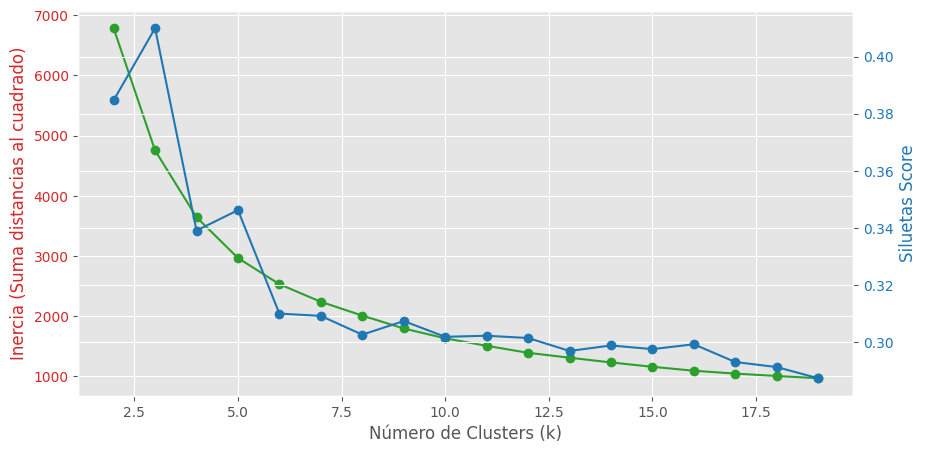

In [8]:
rangos = range(2, 20)
inercias = []
silhouette_scores = []

for k in rangos:
  kmedios = KMeans(n_clusters=k, random_state=42,n_init=20)
  kmedios.fit(X_scaled_df)
  inercias.append(kmedios.inertia_)
  silhouette_scores.append(silhouette_score(X_scaled_df,kmedios.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Suma distancias al cuadrado)', color='tab:red')
ax1.plot(rangos, inercias, marker='o', color='tab:green', label='Inercia')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Siluetas Score', color='tab:blue')
ax2.plot(rangos, silhouette_scores, marker='o', color='tab:blue', label='Siluetas Score')
ax2.tick_params(axis='y', labelcolor='tab:blue')


En este primer grafico se puede denotar que donde mejor se diferencian los grupos es con 3 clusters.

## Entrenamiento modelo
Aca es donde sucede la magiaaaa!!

In [9]:
k = 3

kmeans = KMeans(n_clusters= k ,random_state=42, n_init=20)
kmeans.fit(X_scaled_df)

df['cluster'] = kmeans.labels_

df.to_csv('completo_clusters.csv', index=False)

display(df.head())

,Total_Vehiculos,Tiempo_Medio_s,Ocupacion_Espacial_%,Hora_Inicio,Hora_Fin,Dia_Semana,Direccion,move_time_s,cluster
0,9,3.74,20.96,07:58:35,07:59:08,4,3,33,0
1,7,4.02,17.87,07:59:13,07:59:46,4,4,33,0
2,3,1.90,7.46,07:59:51,08:00:24,4,2,33,1
3,7,4.23,19.05,08:00:29,08:01:02,4,1,33,0
4,8,1.80,20.82,08:01:07,08:01:40,4,3,33,0


Okey no interpreto nada con los datos en crudo, vamos a añadir graficos 

## Representacion mediante graficos
Esto ayuda a entender en su totalidad los datos

1. Muestro los centroides

In [10]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled_df.columns
)

display(centroids)


,Total_Vehiculos,Tiempo_Medio_s,Ocupacion_Espacial_%
0,0.952040,-0.284204,0.966890
1,-0.566774,-0.117888,-0.578647
2,-0.926173,3.059067,-0.911219


#### Podemos denotar que en el 

0. Muchos vehículos (0.95), Ocupación alta (0.97) y Intervalo Bajo (-0.28).
1. Vehiculos moderados (-0.56), Ocupacion moderada ( -0.57) y un tiempo modederado (-0.11)
2. Muy pocos vehículos (-0.93), Ocupación nula (-0.91) y Intervalo Altísimo (3.06). 

2- Vistas de grafico y simplificacion con PCA 

[0.61840026 0.30171166]


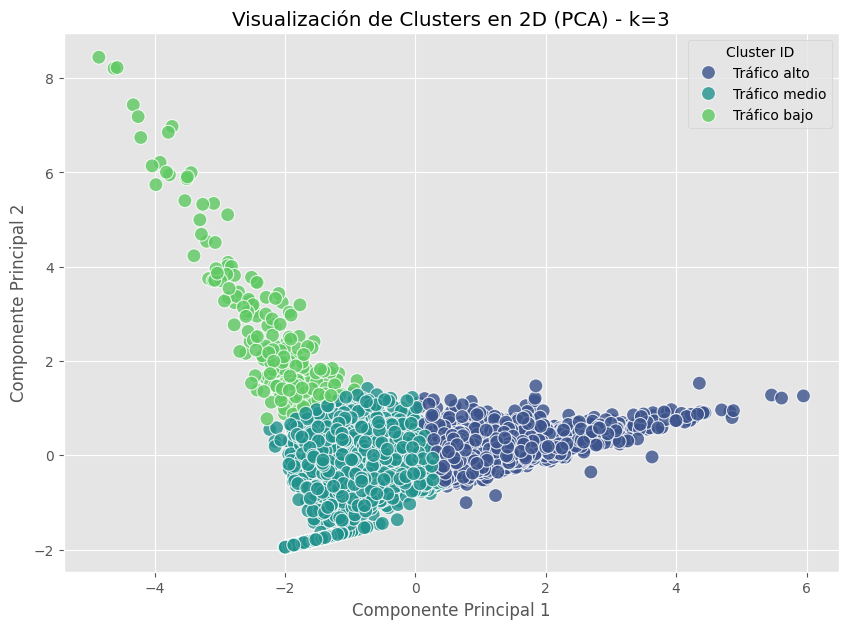

In [11]:
cluster_names = {
    0: 'Tráfico alto',
    1: 'Tráfico medio',
    2: 'Tráfico bajo'
}

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)
print(pca.explained_variance_ratio_)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['cluster']
pca_df['Cluster_name'] = pca_df['Cluster'].map(cluster_names)

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2',  hue='Cluster_name', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title(f'Visualización de Clusters en 2D (PCA) - k={k}')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster ID')
plt.show()